## Diseño del modelo de CNN como calsificador binario

Loss (Función de pérdida): Binary Crossentropy
✔ Optimizador: Adam
✔ Inicialización: Glorot Uniform
✔ CNN:
- Activación convolucional: tanh
- Activación capas densas: ReLU
- Mismo nº filtros, kernel y pool en todas las conv layers
- MaxPooling = 2
- Máx 10 capas convolucionales

✔ Capa Densa:

Cada capa tiene la mitad de neuronas que la anterior

✔ Entrenamiento:

Dataset balanceado (light vs dark): 1000 light y 1000 dark

Split: 80% train / 20% validation

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, initializers
from sklearn.model_selection import train_test_split
import matplotlib.ticker as ticker

I0000 00:00:1776343071.607596   11534 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776343071.770708   11534 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776343074.797819   11534 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
tree_light_data = uproot.open("TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root")["alazar_data"]
tree_light_parameters = uproot.open("TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root")["alazar_parameters"]
tree_dark_data = uproot.open("TES1-0.3RN-5GHz-50MHz-extrinsic-2d-trigger-10mV.root")["alazar_data"]
tree_dark_parameters = uproot.open("TES1-0.3RN-5GHz-50MHz-extrinsic-2d-trigger-10mV.root")["alazar_parameters"]
light_pulses = tree_light_data["dataChA"].array(library="np")
dark_pulses = tree_dark_data["dataChA"].array(library="np")

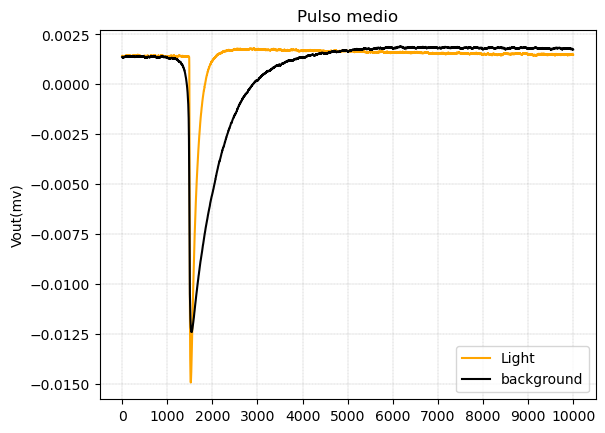

In [3]:
mean_light = np.mean(light_pulses, axis=0)
mean_dark = np.mean(dark_pulses, axis=0)

plt.plot(mean_light, label="Light", color = 'orange')
plt.plot(mean_dark, label="background", color = 'black')

plt.legend()
plt.title("Pulso medio")
plt.ylabel("Vout(mv)")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.2)
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
plt.show()

## División del conjunto de datos
Incialmente trabajaremos con los 4722 pulsos. Sin embargo, para reducir la carga computacional durante el entrenamiento del modelo, se ha decidido seleccionar una ventana de muestras significativas. Para ello se ha calculado el pulso medio del conjunto de datos light y dark. Se observa que la media en ambos casos se centra en el margen de muestra de 1000 a 2000 muestras. Ajustando un poco más, se ha tomado como inicio 1200 como inicio. Se observa que los pulsos dark tienen mayor dispersión, para que el modelo tenga más información de los pulsos dark, se ha decidido, tomar como limite final, 2200.

Otros detalles:
- Hasta este punto, tanto el conjunto de datos light como dark son arrays unidimensionales, cada uno de ellos compuestos por arrays de 10.000 muestras.
Para facilitar la manejabilidad, los aplanaremos en arrays bidemensionales con la función flatten.

In [4]:
n_samples = 1000
ventana_ini = 1200
ventana_fin = 2200
X_light = np.array([fila[ventana_ini:ventana_fin] for fila in light_pulses[:n_samples].flatten()])
X_dark = np.array([fila[ventana_ini:ventana_fin] for fila in dark_pulses[:n_samples].flatten()])

print(X_light.shape)
print(type(X_light))
print(X_dark.shape)

(1000, 1000)
<class 'numpy.ndarray'>
(1000, 1000)


### Etiquetado de los pulsos light y dark

Ya tenemos dividido el conjunto de variables independientes (o características):
- X_light : para los light pulses.
- X_dark : para los dark pulses. 
Ahora debemos crear el conjunto de variables dependientes (o etiquetas) para cada conjunto.
- y_light : 1, para light pulses. Dimension: (1000)
- y_dark: 0, para dark pulses: (1000)

"estas 1000 muestras es un pulso light"  
"estas 1000 muestras es un pulso dark"  
Así para los 1000 pulsos de cada conjunto de datos.


In [5]:
# Etiquetas: los pulsos light tendrán etiqueta 1 y los dark 0
y_light = np.ones(n_samples)
y_dark = np.zeros(n_samples)

In [6]:
print(type(y_light))
print(y_light.shape)
print(type(y_dark))
print(y_dark.shape)

<class 'numpy.ndarray'>
(1000,)
<class 'numpy.ndarray'>
(1000,)


In [7]:
print(X_light[0])
print(X_dark[0])

[ 4.44419013e-03  4.44419013e-03  3.75753414e-03  3.26161593e-03
  3.75753414e-03  4.55863279e-03  4.21530480e-03  3.71938659e-03
  3.03273060e-03  3.26161593e-03  4.17715724e-03  3.52864881e-03
  3.10902571e-03  2.68940261e-03  1.77386130e-03  1.43053330e-03
  6.29434653e-04  1.16350042e-03  1.77386130e-03  2.11718929e-03
  2.19348440e-03  1.69756619e-03  9.34615091e-04  1.12535286e-03
  1.16350042e-03  2.04089418e-03  1.92645151e-03  1.81200885e-03
  2.34607462e-03  1.43053330e-03  1.81200885e-03  1.58312352e-03
  1.77386130e-03  2.04089418e-03  1.88830396e-03  2.49866484e-03
  1.43053330e-03  1.88830396e-03  1.81200885e-03  2.26977951e-03
  2.49866484e-03  2.80384527e-03  2.23163195e-03  2.30792706e-03
  2.23163195e-03  2.57495995e-03  2.11718929e-03  1.69756619e-03
  1.88830396e-03  1.92645151e-03  2.23163195e-03  2.88014038e-03
  2.61310750e-03  2.07904173e-03  1.85015640e-03  2.00274662e-03
  1.43053330e-03  1.04905776e-03  1.31609064e-03  1.50682841e-03
  1.54497597e-03  1.54497

### Concatenar y mezclar
Juntar los pulsos light y dark en un solo conjunto y las etiquetas, luego se mezclan para que el aprendizaje no sea sesgado.

In [6]:
# Combinar
X = np.concatenate([X_light, X_dark], axis=0)
y = np.concatenate([y_light, y_dark], axis=0)

# Shuffle
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]


In [ ]:
print(X[1])
print(X.shape)

### Normalización de los datos

In [7]:
X = (X - np.mean(X)) / np.std(X)

### Añadimos dimensión de canal
Las redes Neuronales esperan datos con la forma:  

(batch, longitud, canales)  = (2000,1000,1)  

Al tratarse de señales 1D, la dimensión del canal es 1.

In [8]:
X = X[..., np.newaxis]  # (2000, 10000, 1)

### Division de los datos en bloques de entrenamiento validación y test

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y
)

### Construcción del modelo de CNN
- input_shape=(800, 1): Es el tamaño de los datos que recibirá la red. En tu caso, espera una señal de 800 puntos de datos y 1 solo canal (como un pulso de luz de una sola dimensión)
- num_conv_layers=3: Define cuántas "capas de convolución" tendrá la red. Estas capas son las que detectan patrones (picos, valles, pendientes) en tus señales
- num_filters=32: Es el número de "neuronas" o detectores en cada capa convolucional. Más filtros permiten detectar patrones más complejos, pero consumen más memoria
- kernel_size=5: Es el ancho de la "ventana" que desliza la red sobre tu señal. Un 5 significa que la red mira los puntos de 5 en 5 para buscar características
- dense_initial_units=128: Tras las capas de convolución, vienen las capas "densas" (clásicas). Este número indica cuántas neuronas tendrá la primera de esas capas.
- num_dense_layers=2: Indica cuántas capas de neuronas tradicionales habrá al final de la red antes de dar el resultado
- dropout_rate=0.3: Es una técnica de "apagado aleatorio" del 30% de las neuronas durante el entrenamiento. Sirve para evitar el overfitting (que la red memorice los datos en lugar de aprender).

In [10]:
from keras.layers import Conv1D

"We further require that all of the
convolutional layers share the same number of filters, filter size, and pool size. We
fix the pool size to 2, limiting the maximum number of convolutional layers in the
considered architecture to 1"

In [11]:
def build_cnn(input_shape, num_conv_layers, num_filters, kernel_size, dense_initial_units, num_dense_layers, dropout_rate):
    
    model = models.Sequential() #modelo en cadena, una capa tras otra

    initializer = initializers.GlorotUniform() #en el articulo usan esta funcion para inicializar los pesos

    # Capas convolucionales
    for i in range(num_conv_layers):
        if i == 0:
            model.add(layers.Conv1D(
                filters=num_filters,
                kernel_size=kernel_size,
                activation='tanh',
                kernel_initializer=initializer,
                input_shape=input_shape
            ))
        else:
            model.add(layers.Conv1D(
                filters=num_filters,
                kernel_size=kernel_size,
                activation='tanh',
                kernel_initializer=initializer
            ))

        model.add(layers.MaxPooling1D(pool_size=2))

    model.add(layers.Flatten())

    # Capas densas (reducción a la mitad)
    units = dense_initial_units
    for _ in range(num_dense_layers):
        model.add(layers.Dense(
            units,
            activation='relu',
            kernel_initializer=initializer
        ))
        model.add(layers.Dropout(dropout_rate))
        units = units // 2

    # Salida binaria
    model.add(layers.Dense(1, activation='linear'))

    # Compilación
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_cnn(
    input_shape=(1000,1),
    num_conv_layers=2, #en  me dicen que son 3, ya revisaremos...     
    num_filters=32,
    kernel_size=5,
    dense_initial_units=128,
    num_dense_layers=2,
    dropout_rate=0.3
)

model.summary()

/home/josue/miniconda3/envs/ML_ROOT/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1776343285.485957   11534 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 996, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 498, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 494, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 247, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7904)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,011,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025,505 (3.91 MB)

 Trainable params: 1,025,505 (3.91 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#entrenamiento del modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
 3/50 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.6076 - loss: 4.7501

W0000 00:00:1775851490.867199   21601 cpu_allocator_impl.cc:82] Allocation of 24976640 exceeds 10% of free system memory.
W0000 00:00:1775851490.859053   21604 cpu_allocator_impl.cc:82] Allocation of 24976640 exceeds 10% of free system memory.
W0000 00:00:1775851490.954495   21604 cpu_allocator_impl.cc:82] Allocation of 24976640 exceeds 10% of free system memory.
W0000 00:00:1775851490.954935   21599 cpu_allocator_impl.cc:82] Allocation of 24976640 exceeds 10% of free system memory.
W0000 00:00:1775851491.024202   21604 cpu_allocator_impl.cc:82] Allocation of 24976640 exceeds 10% of free system memory.


50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.7506 - loss: 3.8363 - val_accuracy: 0.7500 - val_loss: 3.9860
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.7788 - loss: 3.4862 - val_accuracy: 0.7500 - val_loss: 3.9860
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.7800 - loss: 3.4990 - val_accuracy: 0.7500 - val_loss: 3.9860
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.7738 - loss: 3.5736 - val_accuracy: 0.7475 - val_loss: 3.9915
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7800 - loss: 3.4904 - val_accuracy: 0.7500 - val_loss: 3.9860
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.7744 - loss: 3.5661 - val_accuracy: 0.7500 - val_loss: 3.9860
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.7812 - loss: 3.4880 - val_accuracy: 0.7500 - val_loss: 3.9860
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.7794 - loss: 3.5083 - val_accuracy: 0.7500 - val_loss: 3.

#### Evaluación
Evaluamos el rendimiento del modelo ya entrenado con los datos de validación. Tenemos una precisión del 75%

In [14]:
loss, acc = model.evaluate(X_val, y_val)
print(f"Validation accuracy: {acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7500 - loss: 3.9860
Validation accuracy: 0.7500


### Preparacion datos para Autoencoder

Por la propia naturaleza del autoencoder:
Input -> ENCODER -> COMPRESS CODE -> DECODER -> Input reconstructed  

Tenemos dos caminos (probaremos ambos y nos quedaremos con el mejor):

1) Pasaremos como datos de entrenamiento solo pulsos dark para que pueda el modelo aprenda que forma tienen los pulsos dark y así los pueda discrinar un pulso dark de uno light.  
Además seguirá la misma distribución de datos para reducir la carga computacional, es decir tomaremos una venta de muestras significativa.  
- para la CNN cogíamos 1000 datos light + 1000 datos dark
- para seguir la misma distribución, para el encoder usaremos 2000 datos dark

2) Entrenamos el modelo con los dos tipos de pulsos. Y luego pintamos el diagrama para observar la distribución que sigue la representación de cada pulso.

In [ ]:
n_samples_encoder = 2000
X_dark_encoder = np.array([fila[ventana_ini:ventana_fin] for fila in dark_pulses[:n_samples_encoder].flatten()])

# Normalización
# X = (X - np.mean(X)) / np.std(X)
X_train_encoder = (X_dark_encoder - X_dark_encoder.mean()) / X_dark_encoder.std()

# Añadir canal
X_train_encoder = X_train_encoder[..., np.newaxis]


#### Construimos el conjunto de datos para train y validación
Para los datos de validación usaremos los dos tipos (light y dark)

In [ ]:
#X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y)


### Contrucción del Autoencoder

In [ ]:
def build_autoencoder(input_shape, code_dim):

    # Encoder
    input_layer = layers.Input(shape=input_shape)
    encoded = layers.Dense(256, activation ="relu")(input_layer)
    encoded = layers.Dense(128, activation ="relu")(encoded)
    encoded = layers.Dense(64, activation ="relu")(encoded)
    encoded = layers.Dense(32, activation ="relu")(encoded)
    
    # Bottleneck
    #en este caso el tamaño del codigo sera de 16
    bottleneck = layers.Dense(code_dim, activation="linear",name="bottleneck")(encoded)

    # Decoder
    decoded = layers.Dense(32, activation="relu")(bottleneck)
    decoded = layers.Dense(64, activation='relu')(decoded)
    decoded = layers.Dense(128, activation='relu')(decoded)
    decoded = layers.Dense(256, activation='relu')(decoded)
    output_layer = layers.Dense(input_shape, activation='linear')(decoded)

    # Modelo completo
    autoencoder = models.Model(input_layer, output_layer)

    # Compilación
    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss='mse'  # reconstrucción
    )

    return autoencoder

In [ ]:
autoencoder = build_autoencoder(input_shape = (1000,1), code_dim = 16)

autoencoder.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1000, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 500, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 250, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 500, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 1000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 1000, 32)       │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 1000, 1)        │           161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,809 (61.75 KB)

 Trainable params: 15,809 (61.75 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del modelo solo con ruido (Pulsos DARK)

In [ ]:
history = autoencoder.fit(
    X_train_encoder, X_train_encoder,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    shuffle=True
)

### Reconstruccion y evalucación

In [ ]:
reconstructions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)

# Umbral (ejemplo)
threshold = np.percentile(mse, 95)

predictions = mse > threshold  # True = posible "light"

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


### Error de reconstrucción por pulso